
# Mood Inference from Audio Features

This notebook specfically works on mood inference using audio features. 
Audio features such as **valence**, **energy**, and **danceability** help deduce different emotions from a song, and can be used to find out the emotion of a song.

## Importing Libraries

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the dataset

In [17]:
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
df = pd.read_csv(PROCESSED_DIR / "spotify_combined_audio_features.csv")
print(df.shape)
df.head()

(107572, 14)


,track_id,track_name,track_artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,source_dataset
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.945817,1.089463,1.126436,0.0583,0.1020,0.000000,0.0653,0.171828,0.005766,194754,spotify_dataset_1
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,0.820251,0.675769,0.650968,0.0373,0.0724,0.004210,0.3570,0.851832,-0.745115,162600,spotify_dataset_1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,0.529167,1.150903,0.963942,0.0742,0.0794,0.000023,0.1100,0.540973,0.072877,176616,spotify_dataset_1
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.774591,1.146807,0.893487,0.1020,0.0287,0.000009,0.2040,-0.764635,0.003043,169093,spotify_dataset_1
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,0.386478,0.749496,0.711445,0.0359,0.0803,0.000000,0.0833,0.976176,0.071787,189052,spotify_dataset_1


## Selecting Audio Features to detect Mood

Mood inference is primary based on two major audio features : **Valence** and **Energy**

In [19]:
required_cols = ["valence", "energy"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df[required_cols].describe()

,valence,energy
count,1.075720e+05,1.075720e+05
mean,1.321055e-16,-2.071415e-16
std,1.000005e+00,1.000005e+00
min,-1.840985e+00,-2.662461e+00
25%,-8.229212e-01,-6.595230e-01
50%,-3.411630e-02,1.719623e-01
75%,8.013175e-01,8.314162e-01
max,2.025325e+00,1.433526e+00


In [20]:
df["valence"] = pd.to_numeric(df["valence"], errors="coerce")
df["energy"] = pd.to_numeric(df["energy"], errors="coerce")
df = df.dropna(subset=["valence", "energy"])

## Median Threshold

In [21]:
valence_thr = df["valence"].median()
energy_thr = df["energy"].median()

print("Valence threshold (median):", valence_thr)
print("Energy threshold (median):", energy_thr)

Valence threshold (median): -0.0341162995440146
Energy threshold (median): 0.1719622836426368


## Mood Categories

Mood categories are assigned using the median threshold of valence and energy. This rule based approach provides a simple baseline method for mood inference. 

In [22]:
def assign_mood(v, e, v_thr, e_thr):
    if v >= v_thr and e >= e_thr:
        return "Happy / Energetic"
    elif v >= v_thr and e < e_thr:
        return "Calm / Content"
    elif v < v_thr and e >= e_thr:
        return "Angry / Intense"
    else:
        return "Sad / Melancholic"

df["mood_label"] = df.apply(lambda r: assign_mood(r["valence"], r["energy"], valence_thr, energy_thr), axis=1)
df["mood_label"].value_counts()

mood_label
Happy / Energetic    30981
Sad / Melancholic    30858
Calm / Content       22871
Angry / Intense      22862
Name: count, dtype: int64

## Distribution of Mood Categories

After assigning mood labels, the distribution of moods across the dataset is visualized.

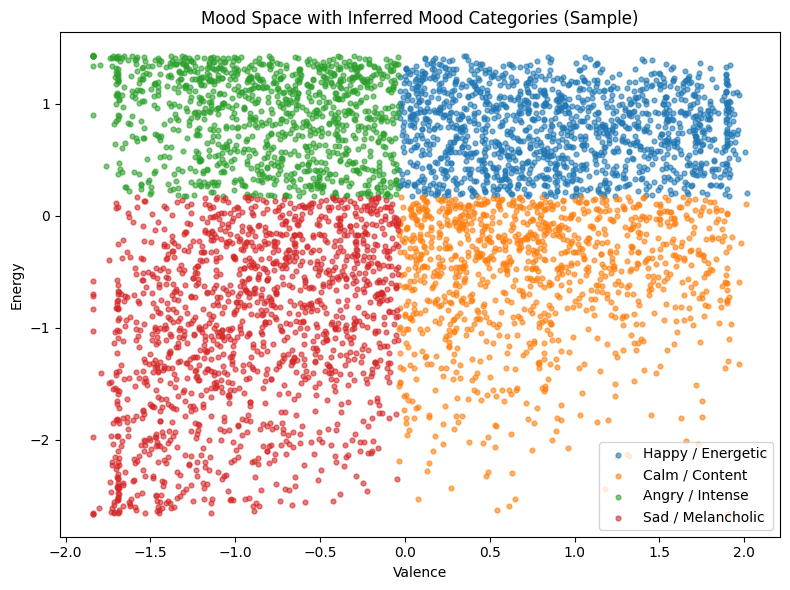

In [23]:
sample = df.sample(n=5000, random_state=42)
plt.figure(figsize=(8, 6))

for mood in ["Happy / Energetic", "Calm / Content", "Angry / Intense", "Sad / Melancholic"]:
    subset = sample[sample["mood_label"] == mood]
    plt.scatter(subset["valence"], subset["energy"], s=12, alpha=0.6, label=mood)

plt.xlabel("Valence")
plt.ylabel("Energy")
plt.title("Mood Space with Inferred Mood Categories (Sample)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "week3_mood_space_with_labels.png"), dpi=200)
plt.show()

## Relationship Between Audio Features and Mood

Scatter plots are used to visualize how audio features such as valence and energy relate to mood categories.


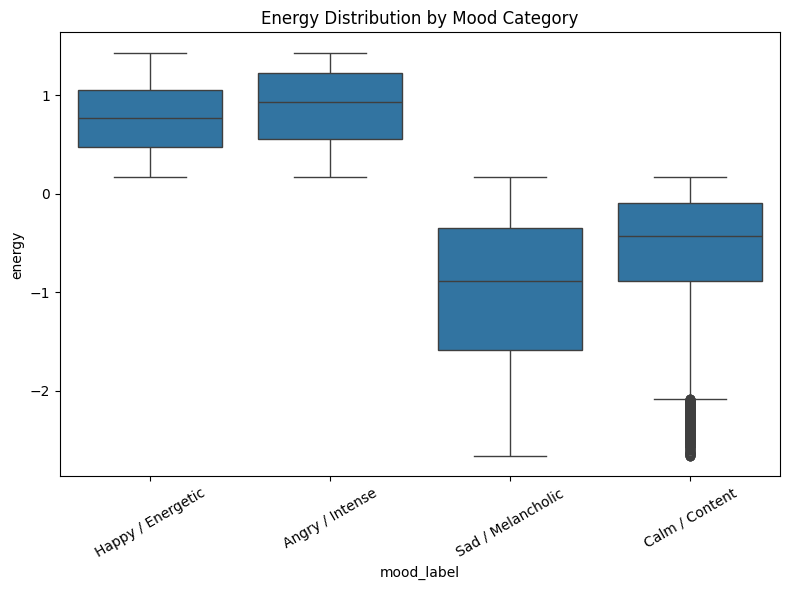

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="mood_label",
    y="energy"
)

plt.xticks(rotation=30)
plt.title("Energy Distribution by Mood Category")

plt.tight_layout()
plt.savefig(FIG_DIR / "week3_energy_by_mood.png", dpi=200)
plt.show()

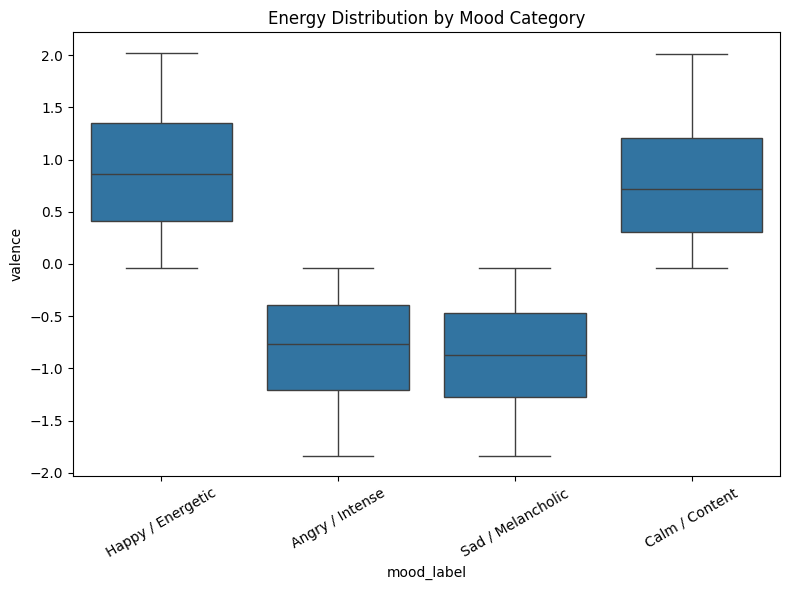

In [25]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="mood_label",
    y="valence"
)

plt.xticks(rotation=30)
plt.title("Energy Distribution by Mood Category")

plt.tight_layout()
plt.savefig(FIG_DIR / "week3_valence_by_mood.png", dpi=200)
plt.show()

In [26]:
mood_profile_features = ["valence", "energy"]
df[mood_profile_features].head()

,valence,energy
0,0.171828,1.089463
1,0.851832,0.675769
2,0.540973,1.150903
3,-0.764635,1.146807
4,0.976176,0.749496


## FINAL OUTPUT

The dataset containing mood labels is saved for use in later stages of project. 

In [27]:
OUTPUT_PATH = PROCESSED_DIR / "spotify_dataset_with_mood.csv"
df.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH)

Saved to: /Users/srs/Desktop/REGIS/MSDS692- DATA SCIENCE PRACTICUM/practicum_1_mood_detection_using_music_recommendation_system/data/processed/spotify_dataset_with_mood.csv
